# TH03. Phân loại — Breast Cancer Wisconsin


## Import thư viện

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

sns.set_style("whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
RANDOM_STATE = 42

# Câu 1: Nạp và khảo sát bộ dữ liệu — 5 điểm
### Bước 1.1. Nạp dữ liệu

In [3]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")
df = X.copy()
df["target"] = y

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Target names:", list(data.target_names))

X shape: (569, 30)
y shape: (569,)
Number of samples: 569
Number of features: 30
Target names: ['malignant', 'benign']


In [4]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.9900,10.3800,122.8000,1001.0000,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,...,17.3300,184.6000,2019.0000,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,0
1,20.5700,17.7700,132.9000,1326.0000,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,...,23.4100,158.8000,1956.0000,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890,0
2,19.6900,21.2500,130.0000,1203.0000,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,...,25.5300,152.5000,1709.0000,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876,0
3,11.4200,20.3800,77.5800,386.1000,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,...,26.5000,98.8700,567.7000,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730,0
4,20.2900,14.3400,135.1000,1297.0000,0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,...,16.6700,152.2000,1575.0000,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768,0


In [5]:
df.tail()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
564,21.5600,22.3900,142.0000,1479.0000,0.1110,0.1159,0.2439,0.1389,0.1726,0.0562,...,26.4000,166.1000,2027.0000,0.1410,0.2113,0.4107,0.2216,0.2060,0.0712,0
565,20.1300,28.2500,131.2000,1261.0000,0.0978,0.1034,0.1440,0.0979,0.1752,0.0553,...,38.2500,155.0000,1731.0000,0.1166,0.1922,0.3215,0.1628,0.2572,0.0664,0
566,16.6000,28.0800,108.3000,858.1000,0.0846,0.1023,0.0925,0.0530,0.1590,0.0565,...,34.1200,126.7000,1124.0000,0.1139,0.3094,0.3403,0.1418,0.2218,0.0782,0
567,20.6000,29.3300,140.1000,1265.0000,0.1178,0.2770,0.3514,0.1520,0.2397,0.0702,...,39.4200,184.6000,1821.0000,0.1650,0.8681,0.9387,0.2650,0.4087,0.1240,0
568,7.7600,24.5400,47.9200,181.0000,0.0526,0.0436,0.0000,0.0000,0.1587,0.0588,...,30.3700,59.1600,268.6000,0.0900,0.0644,0.0000,0.0000,0.2871,0.0704,1


**Nhận xét:** Bộ dữ liệu Breast Cancer Wisconsin gồm 569 mẫu và 30 đặc trưng số học được trích xuất từ ảnh sinh thiết tế bào. Biến mục tiêu target gồm hai lớp: 0 = malignant (ác tính) và 1 = benign (lành tính).


### Bước 1.2. Kiểm tra cấu trúc dữ liệu

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [7]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,...,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000
mean,14.1273,19.2896,91.9690,654.8891,0.0964,0.1043,0.0888,0.0489,0.1812,0.0628,...,25.6772,107.2612,880.5831,0.1324,0.2543,0.2722,0.1146,0.2901,0.0839,0.6274
std,3.5240,4.3010,24.2990,351.9141,0.0141,0.0528,0.0797,0.0388,0.0274,0.0071,...,6.1463,33.6025,569.3570,0.0228,0.1573,0.2086,0.0657,0.0619,0.0181,0.4839
min,6.9810,9.7100,43.7900,143.5000,0.0526,0.0194,0.0000,0.0000,0.1060,0.0500,...,12.0200,50.4100,185.2000,0.0712,0.0273,0.0000,0.0000,0.1565,0.0550,0.0000
25%,11.7000,16.1700,75.1700,420.3000,0.0864,0.0649,0.0296,0.0203,0.1619,0.0577,...,21.0800,84.1100,515.3000,0.1166,0.1472,0.1145,0.0649,0.2504,0.0715,0.0000
50%,13.3700,18.8400,86.2400,551.1000,0.0959,0.0926,0.0615,0.0335,0.1792,0.0615,...,25.4100,97.6600,686.5000,0.1313,0.2119,0.2267,0.0999,0.2822,0.0800,1.0000
75%,15.7800,21.8000,104.1000,782.7000,0.1053,0.1304,0.1307,0.0740,0.1957,0.0661,...,29.7200,125.4000,1084.0000,0.1460,0.3391,0.3829,0.1614,0.3179,0.0921,1.0000
max,28.1100,39.2800,188.5000,2501.0000,0.1634,0.3454,0.4268,0.2012,0.3040,0.0974,...,49.5400,251.2000,4254.0000,0.2226,1.0580,1.2520,0.2910,0.6638,0.2075,1.0000


In [8]:
numerical_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(exclude=[np.number]).columns
missing_values = df.isnull().sum().sum()

print("Number of numerical columns:", len(numerical_cols))
print("Number of categorical columns:", len(categorical_cols))
print("Number of missing values:", missing_values)

Number of numerical columns: 31
Number of categorical columns: 0
Number of missing values: 0


### Bước 1.3. Khảo sát biến mục tiêu

In [9]:
class_counts = y.value_counts().sort_index()
class_percent = (class_counts / len(y) * 100)

target_table = pd.DataFrame({
    "Class": [0, 1],
    "Name": ["malignant", "benign"],
    "Number of samples": class_counts.values,
    "Percentage": class_percent.round(2).astype(str) + "%"
})
target_table

,Class,Name,Number of samples,Percentage
0,0,malignant,212,37.26%
1,1,benign,357,62.74%


**Nhận xét:** Lớp `benign` chiếm 357/569 mẫu (62.74%) trong khi lớp `malignant` chỉ chiếm 212/569 mẫu (37.26%). Tỷ lệ giữa hai lớp xấp xỉ 1.68:1, đây là mức mất cân bằng nhẹ, chưa đến mức nghiêm trọng (thường được xem là nghiêm trọng khi tỷ lệ vượt quá 4:1 hoặc 10:1). Vì vậy Accuracy vẫn có ý nghĩa tham khảo nhưng cần kết hợp thêm Precision, Recall, F1-score để đánh giá đầy đủ, đặc biệt với lớp `malignant` là lớp cần được phát hiện chính xác trong bài toán y khoa.

## Câu 2. Phân tích khám phá dữ liệu (EDA) — 10 điểm
### Bước 2.1. Phân bố lớp

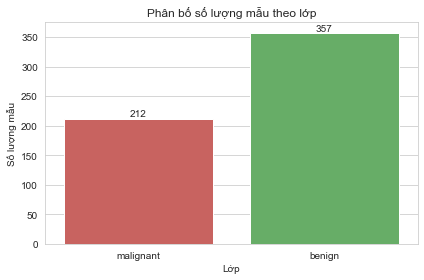

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x=y.map({0: "malignant", 1: "benign"}), palette=["#d9534f", "#5cb85c"], ax=ax)
ax.set_title("Phân bố số lượng mẫu theo lớp")
ax.set_xlabel("Lớp")
ax.set_ylabel("Số lượng mẫu")
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.show()

**Nhận xét:** Biểu đồ cho thấy số lượng mẫu `benign` (357) nhiều hơn `malignant` (212), tương ứng tỷ lệ 62.74% so với 37.26%. Đây là sự mất cân bằng lớp ở mức vừa phải, chưa nghiêm trọng vì lớp thiểu số vẫn chiếm hơn 1/3 tổng số mẫu, đủ để mô hình học được đặc trưng phân biệt của cả hai lớp.

### Bước 2.2. Phân bố mean radius

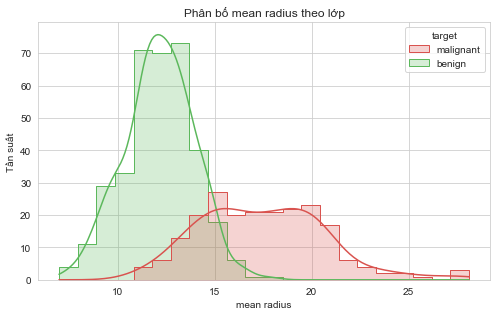

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.histplot(data=df, x="mean radius", hue=df["target"].map({0: "malignant", 1: "benign"}),
             kde=True, palette=["#d9534f", "#5cb85c"], element="step", ax=ax)
ax.set_title("Phân bố mean radius theo lớp")
ax.set_xlabel("mean radius")
ax.set_ylabel("Tần suất")
plt.tight_layout()
plt.show()

**Nhận xét:** Nhóm `malignant` có xu hướng tập trung ở vùng `mean radius` lớn hơn (khoảng 15–20), trong khi nhóm `benign` tập trung ở vùng nhỏ hơn (khoảng 10–13). Hai phân bố có phần chồng lấn ở khoảng giữa (13–15) nhưng nhìn chung `mean radius` là một đặc trưng có khả năng phân tách khá tốt giữa hai lớp.

### Bước 2.3. Boxplot mean texture

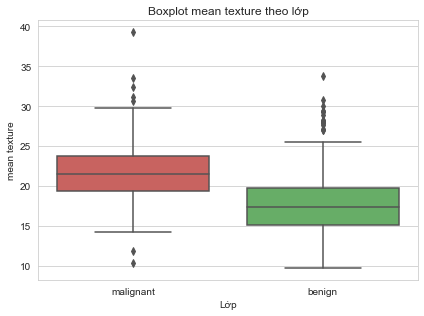

In [12]:
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.boxplot(x=df["target"].map({0: "malignant", 1: "benign"}), y=df["mean texture"],
            palette=["#d9534f", "#5cb85c"], ax=ax)
ax.set_title("Boxplot mean texture theo lớp")
ax.set_xlabel("Lớp")
ax.set_ylabel("mean texture")
plt.tight_layout()
plt.show()

**Nhận xét:** Trung vị `mean texture` của nhóm `malignant` cao hơn nhóm `benign`, cho thấy khối u ác tính thường có kết cấu bề mặt không đồng đều hơn. Độ phân tán (IQR) của hai nhóm khá gần nhau, tuy nhiên cả hai nhóm đều xuất hiện một số giá trị ngoại lai ở phía trên, đặc biệt là nhóm `benign`.

### Bước 2.4. Quan hệ hai đặc trưng

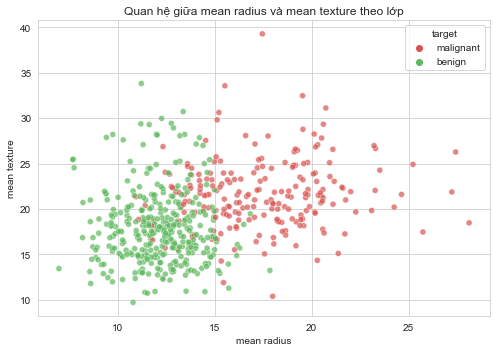

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df, x="mean radius", y="mean texture",
                 hue=df["target"].map({0: "malignant", 1: "benign"}),
                 palette=["#d9534f", "#5cb85c"], alpha=0.7, ax=ax)
ax.set_title("Quan hệ giữa mean radius và mean texture theo lớp")
ax.set_xlabel("mean radius")
ax.set_ylabel("mean texture")
plt.tight_layout()
plt.show()

**Nhận xét:** Trên không gian hai đặc trưng `mean radius` và `mean texture`, hai lớp có xu hướng tách thành hai vùng tương đối riêng biệt: mẫu `malignant` phân bố lệch về phía giá trị lớn của cả hai trục, mẫu `benign` phân bố lệch về phía giá trị nhỏ. Vẫn còn vùng chồng lấn ở giữa, cho thấy chỉ hai đặc trưng này là chưa đủ để phân tách hoàn toàn, cần kết hợp thêm các đặc trưng khác.

### Bước 2.5. Ma trận tương quan

In [14]:
corr_with_target = df.corr()["target"].abs().sort_values(ascending=False)
top10_features = corr_with_target.drop("target").head(10)
print("Top 10 đặc trưng có tương quan tuyệt đối lớn nhất với target:")
top10_features

Top 10 đặc trưng có tương quan tuyệt đối lớn nhất với target:


worst concave points   0.7936
worst perimeter        0.7829
mean concave points    0.7766
worst radius           0.7765
mean perimeter         0.7426
worst area             0.7338
mean radius            0.7300
mean area              0.7090
mean concavity         0.6964
worst concavity        0.6596
Name: target, dtype: float64

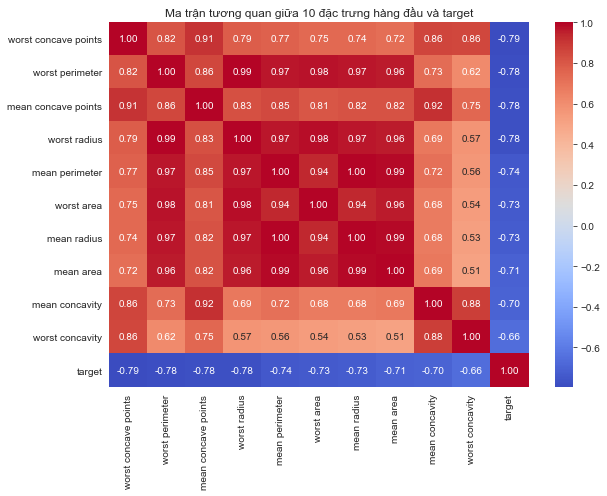

In [15]:
fig, ax = plt.subplots(figsize=(9, 7))
heatmap_cols = list(top10_features.index) + ["target"]
sns.heatmap(df[heatmap_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Ma trận tương quan giữa 10 đặc trưng hàng đầu và target")
plt.tight_layout()
plt.show()

**Nhận xét:** Ba đặc trưng có quan hệ mạnh nhất với biến mục tiêu là `worst concave points` (|r| ≈ 0.79), `worst perimeter` (|r| ≈ 0.78) và `mean concave points` (|r| ≈ 0.78). Đây đều là các đặc trưng liên quan đến hình dạng và kích thước của nhân tế bào, phù hợp với kiến thức y khoa rằng khối u ác tính thường có kích thước lớn hơn và biên dạng bất thường hơn (nhiều điểm lõm) so với khối u lành tính.

## Câu 3. Tiền xử lý dữ liệu — 10 điểm
### Bước 3.1. Kiểm tra dữ liệu thiếu

In [16]:
total_missing = df.isnull().sum().sum()
print("Total missing values:", total_missing)
if total_missing == 0:
    print("Kết luận: Không phát hiện dữ liệu thiếu trong bộ dữ liệu.")
else:
    print("Kết luận: Có dữ liệu thiếu, cần xử lý bằng phương pháp phù hợp (điền giá trị trung bình/median hoặc loại bỏ).")

Total missing values: 0
Kết luận: Không phát hiện dữ liệu thiếu trong bộ dữ liệu.


### Bước 3.2. Kiểm tra dữ liệu trùng lặp

In [17]:
n_duplicates = df.duplicated().sum()
print("Number of duplicated rows:", n_duplicates)
n_before = df.shape[0]
if n_duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    X = df.drop(columns=["target"])
    y = df["target"]
n_after = df.shape[0]
print("Number of samples before removing duplicates:", n_before)
print("Number of samples after removing duplicates:", n_after)

Number of duplicated rows: 0
Number of samples before removing duplicates: 569
Number of samples after removing duplicates: 569


**Nhận xét:** Không phát hiện dòng dữ liệu trùng lặp nào (`Number of duplicated rows = 0`), do đó số mẫu trước và sau bước kiểm tra không đổi (569 mẫu).

### Bước 3.3. Kiểm tra ngoại lai

In [18]:
outlier_features = ["mean radius", "mean texture", "mean area"]
outlier_rows = []
for col in outlier_features:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    n_outliers = ((X[col] < lower_bound) | (X[col] > upper_bound)).sum()
    outlier_rows.append([col, round(Q1, 4), round(Q3, 4), round(IQR, 4), n_outliers])

outlier_table = pd.DataFrame(outlier_rows, columns=["Feature", "Q1", "Q3", "IQR", "Number of outliers"])
outlier_table

,Feature,Q1,Q3,IQR,Number of outliers
0,mean radius,11.7000,15.7800,4.0800,14
1,mean texture,16.1700,21.8000,5.6300,7
2,mean area,420.3000,782.7000,362.4000,25


**Nhận xét:** Cả ba đặc trưng đều có một số lượng nhỏ giá trị nằm ngoài khoảng IQR (14 mẫu với `mean radius`, 7 mẫu với `mean texture`, 25 mẫu với `mean area`). Trong dữ liệu y khoa, các giá trị bất thường này chưa chắc là dữ liệu sai hay nhiễu — chúng có thể phản ánh các trường hợp lâm sàng thực sự bất thường (ví dụ khối u kích thước rất lớn hoặc rất nhỏ), vốn có giá trị chẩn đoán quan trọng. Vì vậy nhóm không tự động loại bỏ các mẫu này mà chỉ ghi nhận để lưu ý khi phân tích lỗi ở các bước sau.

### Bước 3.4. Chia dữ liệu

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (455, 30)
X_test shape: (114, 30)
y_train shape: (455,)
y_test shape: (114,)


In [20]:
split_table = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Malignant": [ (y_train == 0).sum(), (y_test == 0).sum() ],
    "Benign": [ (y_train == 1).sum(), (y_test == 1).sum() ]
})
split_table

,Dataset,Malignant,Benign
0,Train,170,285
1,Test,42,72


**Nhận xét:** Nhờ tham số `stratify=y`, tỷ lệ giữa hai lớp trong tập Train (170 malignant / 285 benign) và tập Test (42 malignant / 72 benign) đều xấp xỉ tỷ lệ gốc 37.26%/62.74%, đảm bảo tập test đại diện đúng cho phân bố dữ liệu gốc.


### Bước 3.5. Chuẩn hóa dữ liệu

In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
first5 = X_train_scaled_df.iloc[:, :5]

scaling_check = pd.DataFrame({
    "Mean": first5.mean(),
    "Std": first5.std()
})
scaling_check

,Mean,Std
mean radius,-0.0000,1.0011
mean texture,0.0000,1.0011
mean perimeter,-0.0000,1.0011
mean area,0.0000,1.0011
mean smoothness,0.0000,1.0011


**Trả lời:** StandardScaler không được fit trên toàn bộ dữ liệu trước khi chia train/test vì làm như vậy sẽ khiến thông tin thống kê (mean, std) của tập test bị "rò rỉ" (data leakage) vào quá trình chuẩn hóa của tập train. Điều này làm cho việc đánh giá mô hình trên tập test không còn khách quan, vì mô hình gián tiếp đã "nhìn thấy" một phần thông tin phân bố của dữ liệu test trong quá trình huấn luyện, dẫn đến đánh giá hiệu năng lạc quan hơn thực tế.

**Nhận xét:** Sau khi chuẩn hóa, giá trị trung bình của 5 đặc trưng đầu tiên trên tập train đều xấp xỉ 0 và độ lệch chuẩn xấp xỉ 1, đúng như tính chất của StandardScaler khi fit trên chính tập train.

## Câu 4. Xây dựng mô hình phân loại — 10 điểm
### Bước 4.1. Tạo mô hình baseline

In [22]:
svm_baseline = SVC(kernel="rbf", C=1.0, gamma="scale")
svm_baseline.fit(X_train_scaled, y_train)
print("Đã huấn luyện xong mô hình SVM baseline trên tập train đã chuẩn hóa.")

Đã huấn luyện xong mô hình SVM baseline trên tập train đã chuẩn hóa.


### Bước 4.2. Dự đoán

In [23]:
y_pred_baseline = svm_baseline.predict(X_test_scaled)

label_map = {0: "malignant", 1: "benign"}
y_test_reset = y_test.reset_index(drop=True)

prediction_table = pd.DataFrame({
    "Sample": range(1, 11),
    "True label": [label_map[v] for v in y_test_reset[:10]],
    "Predicted label": [label_map[v] for v in y_pred_baseline[:10]],
    "Correct": (y_test_reset[:10].values == y_pred_baseline[:10])
})
prediction_table

,Sample,True label,Predicted label,Correct
0,1,malignant,malignant,True
1,2,benign,benign,True
2,3,malignant,malignant,True
3,4,benign,benign,True
4,5,malignant,malignant,True
5,6,benign,benign,True
6,7,benign,benign,True
7,8,malignant,malignant,True
8,9,malignant,malignant,True
9,10,malignant,malignant,True


### Bước 4.3. Giải thích siêu tham số

- **C** (tham số điều chuẩn - regularization): kiểm soát sự đánh đổi giữa việc phân loại đúng toàn bộ mẫu huấn luyện và việc giữ biên phân tách (margin) rộng. C nhỏ cho phép mô hình chấp nhận nhiều điểm bị phân loại sai hoặc nằm trong margin để đổi lấy biên rộng hơn, giúp mô hình đơn giản và ít overfitting hơn nhưng có thể underfitting nếu C quá nhỏ. C lớn buộc mô hình cố gắng phân loại đúng gần như mọi điểm huấn luyện, làm biên hẹp lại và mô hình dễ overfitting trên dữ liệu nhiễu.
- **kernel**: quyết định không gian đặc trưng mà SVM dùng để tìm siêu phẳng phân tách. Kernel `linear` phù hợp khi dữ liệu có thể phân tách gần như tuyến tính, trong khi `rbf` ánh xạ dữ liệu sang không gian nhiều chiều hơn giúp xử lý các ranh giới phi tuyến phức tạp. Việc chọn sai kernel có thể khiến mô hình không nắm bắt được cấu trúc thực sự của dữ liệu (underfitting) hoặc học cả nhiễu (overfitting).
- **gamma**: (áp dụng với kernel phi tuyến như `rbf`, `poly`, `sigmoid`) kiểm soát mức độ ảnh hưởng của một điểm dữ liệu huấn luyện lên vùng xung quanh nó. Gamma nhỏ nghĩa là mỗi điểm có ảnh hưởng lan rộng, tạo ra ranh giới quyết định mượt và đơn giản hơn (dễ underfitting). Gamma lớn khiến ảnh hưởng của mỗi điểm chỉ giới hạn ở vùng lân cận rất gần, tạo ra ranh giới phức tạp, uốn lượn sát theo từng điểm huấn luyện, dễ dẫn đến overfitting.

## Câu 5. Đánh giá mô hình — 15 điểm
### Bước 5.1. Tính các chỉ số

In [24]:
accuracy = accuracy_score(y_test, y_pred_baseline)
precision = precision_score(y_test, y_pred_baseline)
recall = recall_score(y_test, y_pred_baseline)
f1 = f1_score(y_test, y_pred_baseline)

metrics_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [f"{accuracy:.4f}", f"{precision:.4f}", f"{recall:.4f}", f"{f1:.4f}"]
})
metrics_table

,Metric,Value
0,Accuracy,0.9825
1,Precision,0.9861
2,Recall,0.9861
3,F1-score,0.9861


### Bước 5.2. Classification report

In [25]:
print(classification_report(y_test, y_pred_baseline, target_names=data.target_names, digits=4))

              precision    recall  f1-score   support

   malignant     0.9762    0.9762    0.9762        42
      benign     0.9861    0.9861    0.9861        72

    accuracy                         0.9825       114
   macro avg     0.9812    0.9812    0.9812       114
weighted avg     0.9825    0.9825    0.9825       114



### Bước 5.3. Confusion Matrix

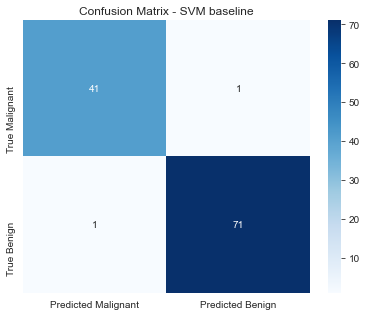

TN = 41; FP = 1; FN = 1; TP = 71


In [26]:
cm = confusion_matrix(y_test, y_pred_baseline)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Malignant", "Predicted Benign"],
            yticklabels=["True Malignant", "True Benign"], ax=ax)
ax.set_title("Confusion Matrix - SVM baseline")
plt.tight_layout()
plt.show()

print(f"TN = {tn}; FP = {fp}; FN = {fn}; TP = {tp}")

**Nhận xét**: 
- Độ chính xác tổng thể cao: 112/114 mẫu dự đoán đúng (TN=41, TP=71), chỉ sai 2/114.
- FP = 1: 1 ca lành tính (Benign) bị dự đoán nhầm thành ác tính (Malignant) — gây lo lắng/thăm khám thừa nhưng không nguy hiểm tính mạng.
- FN = 1: 1 ca ác tính (Malignant) bị bỏ sót, dự đoán nhầm thành lành tính — đây là loại lỗi nghiêm trọng hơn trong bài toán y tế vì có thể bỏ sót ung thư.
- Model cân bằng tốt giữa hai lớp, không thiên lệch rõ rệt về phía nào (FP và FN bằng nhau).

### Bước 5.4. Phân tích lỗi

In [27]:
n_wrong = (y_test.values != y_pred_baseline).sum()
malignant_as_benign = fn
benign_as_malignant = fp

print("Số mẫu bị dự đoán sai:", n_wrong)
print("Số malignant bị dự đoán thành benign (FN):", malignant_as_benign)
print("Số benign bị dự đoán thành malignant (FP):", benign_as_malignant)

Số mẫu bị dự đoán sai: 2
Số malignant bị dự đoán thành benign (FN): 1
Số benign bị dự đoán thành malignant (FP): 1


**Nhận xét:** Mô hình SVM baseline chỉ dự đoán sai 2/114 mẫu trên tập test, trong đó có 1 mẫu `malignant` bị dự đoán nhầm thành `benign` (false negative) và 1 mẫu `benign` bị dự đoán nhầm thành `malignant` (false positive). Trong bài toán hỗ trợ chẩn đoán ung thư, loại sai số false negative (bỏ sót ca ác tính, chẩn đoán thành lành tính) nguy hiểm hơn nhiều so với false positive, vì bệnh nhân có thể không được điều trị kịp thời, dẫn đến hậu quả nghiêm trọng về sức khỏe. Ngược lại, false positive chỉ dẫn đến việc bệnh nhân được kiểm tra/xét nghiệm thêm, ít nguy hiểm hơn. Do đó, dù số lượng lỗi hiện tại rất thấp, Recall của lớp `malignant` cần được ưu tiên theo dõi sát trong các cải tiến tiếp theo.

## Câu 6. Khảo sát siêu tham số — 10 điểm
### Bước 6.1. Thay đổi C

In [28]:
C_values = [0.01, 0.1, 1, 10, 100]
c_results = []
for C in C_values:
    model_c = SVC(kernel="rbf", C=C, gamma="scale")
    model_c.fit(X_train_scaled, y_train)
    train_acc = model_c.score(X_train_scaled, y_train)
    y_pred_c = model_c.predict(X_test_scaled)
    test_acc = accuracy_score(y_test, y_pred_c)
    prec_c = precision_score(y_test, y_pred_c)
    rec_c = recall_score(y_test, y_pred_c)
    f1_c = f1_score(y_test, y_pred_c)
    c_results.append([C, train_acc, test_acc, prec_c, rec_c, f1_c])

c_table = pd.DataFrame(c_results, columns=["C", "Train Accuracy", "Test Accuracy", "Precision", "Recall", "F1"])
c_table = c_table.round(4)
c_table

,C,Train Accuracy,Test Accuracy,Precision,Recall,F1
0,0.0100,0.6264,0.6316,0.6316,1.0000,0.7742
1,0.1000,0.9582,0.9474,0.9459,0.9722,0.9589
2,1.0000,0.9824,0.9825,0.9861,0.9861,0.9861
3,10.0000,0.9934,0.9737,0.9859,0.9722,0.9790
4,100.0000,1.0000,0.9474,0.9853,0.9306,0.9571


### Bước 6.2. Trực quan hóa

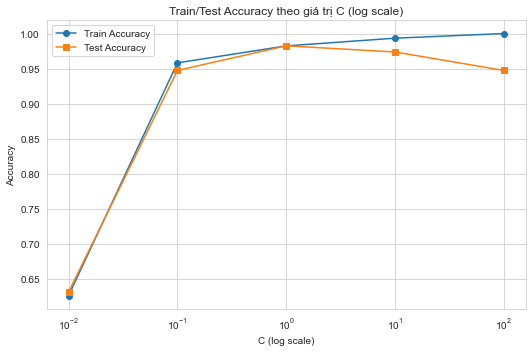

In [29]:
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(c_table["C"], c_table["Train Accuracy"], marker="o", label="Train Accuracy")
ax.plot(c_table["C"], c_table["Test Accuracy"], marker="s", label="Test Accuracy")
ax.set_xscale("log")
ax.set_title("Train/Test Accuracy theo giá trị C (log scale)")
ax.set_xlabel("C (log scale)")
ax.set_ylabel("Accuracy")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

**Nhận xét:** Khi C tăng từ 0.01 đến 100, Train Accuracy tăng liên tục và đạt 1.0 tại C = 100, trong khi Test Accuracy tăng đến C = 1 rồi giảm dần khi C tiếp tục tăng. Khoảng cách giữa Train Accuracy và Test Accuracy ngày càng lớn ở các giá trị C cao, đây là dấu hiệu rõ ràng của overfitting khi C quá lớn.

### Bước 6.3. Thay đổi kernel

In [30]:
kernels = ["linear", "rbf", "poly", "sigmoid"]
kernel_results = []
for k in kernels:
    model_k = SVC(kernel=k, C=1.0, gamma="scale")
    model_k.fit(X_train_scaled, y_train)
    y_pred_k = model_k.predict(X_test_scaled)
    acc_k = accuracy_score(y_test, y_pred_k)
    prec_k = precision_score(y_test, y_pred_k)
    rec_k = recall_score(y_test, y_pred_k)
    f1_k = f1_score(y_test, y_pred_k)
    kernel_results.append([k, acc_k, prec_k, rec_k, f1_k])

kernel_table = pd.DataFrame(kernel_results, columns=["Kernel", "Accuracy", "Precision", "Recall", "F1"])
kernel_table = kernel_table.round(4)
kernel_table

,Kernel,Accuracy,Precision,Recall,F1
0,linear,0.9737,0.9859,0.9722,0.9790
1,rbf,0.9825,0.9861,0.9861,0.9861
2,poly,0.9123,0.8780,1.0000,0.9351
3,sigmoid,0.9298,0.9571,0.9306,0.9437


### Bước 6.4. Chọn mô hình

In [31]:
best_c_row = c_table.loc[c_table["F1"].idxmax()]
best_kernel_row = kernel_table.loc[kernel_table["F1"].idxmax()]

print("Best C =", best_c_row["C"])
print("Best kernel =", best_kernel_row["Kernel"])
print("Best F1-score =", round(max(best_c_row["F1"], best_kernel_row["F1"]), 4))

Best C = 1.0
Best kernel = rbf
Best F1-score = 0.9861


**Nhận xét:** Xét theo F1-score trên tập test, C = 1 đạt F1 cao nhất (0.9861) trong khảo sát C, và kernel `rbf` đạt F1 cao nhất (0.9861) trong khảo sát kernel — trùng với cấu hình baseline. Mặc dù C = 10 và C = 100 cho Train Accuracy cao hơn (thậm chí đạt 1.0 tại C = 100), Test Accuracy và F1 của chúng lại thấp hơn, cho thấy các mô hình này overfitting. Việc lựa chọn mô hình không chỉ dựa vào Accuracy vì Accuracy có thể gây hiểu lầm khi dữ liệu mất cân bằng nhẹ; F1-score cân bằng giữa Precision và Recall nên phản ánh tốt hơn khả năng phát hiện đúng cả hai lớp, đặc biệt là lớp `malignant`. Do đó cấu hình được chọn là **C = 1, kernel = rbf**.

## Câu 7. Phân tích mô hình — 10 điểm
### Bước 7.1. Phân tích dự đoán sai

In [32]:
wrong_mask = (y_test.values != y_pred_baseline)
X_test_reset = X_test.reset_index(drop=True)

error_cols = ["mean radius", "mean texture", "mean perimeter", "mean area",
              "worst radius", "worst perimeter", "worst area"]

error_df = X_test_reset.loc[wrong_mask, error_cols].copy()
error_df.insert(0, "true_label", [label_map[v] for v in y_test_reset[wrong_mask]])
error_df.insert(1, "predicted_label", [label_map[v] for v in y_pred_baseline[wrong_mask]])
error_df = error_df.reset_index(drop=True)
error_df.head(10)

,true_label,predicted_label,mean radius,mean texture,mean perimeter,mean area,worst radius,worst perimeter,worst area
0,benign,malignant,14.4700,24.9900,95.8100,656.4000,16.2200,113.5000,808.9000
1,malignant,benign,13.8000,15.7900,90.4300,584.1000,16.5700,110.3000,812.4000


### Bước 7.2. So sánh dự đoán đúng và sai

In [33]:
correct_mask = ~wrong_mask

compare_rows = []
for col in error_cols:
    correct_mean = X_test_reset.loc[correct_mask, col].mean()
    incorrect_mean = X_test_reset.loc[wrong_mask, col].mean()
    compare_rows.append([col, round(correct_mean, 4), round(incorrect_mean, 4)])

compare_table = pd.DataFrame(compare_rows, columns=["Feature", "Correct predictions", "Incorrect predictions"])
compare_table

,Feature,Correct predictions,Incorrect predictions
0,mean radius,14.3712,14.1350
1,mean texture,19.4418,20.3900
2,mean perimeter,93.6207,93.1200
3,mean area,681.2964,620.2500
4,worst radius,16.6405,16.3950
5,worst perimeter,109.7618,111.9000
6,worst area,928.7804,810.6500


### Bước 7.3. Nhận xét

Mô hình SVM baseline hoạt động rất tốt trên tổng thể, đạt Accuracy 98.25% và F1-score 0.9861, chỉ sai 2/114 mẫu trên tập test. Mô hình gặp khó khăn ở các trường hợp nằm gần ranh giới phân tách giữa hai lớp — cụ thể là các mẫu có giá trị đặc trưng kích thước (radius, perimeter, area) nằm ở vùng chồng lấn giữa nhóm malignant và benign đã quan sát được ở phần EDA (Bước 2.4). Khoảng cách nhỏ giữa Train Accuracy (0.9824) và Test Accuracy (0.9825) tại cấu hình baseline cho thấy không có dấu hiệu overfitting đáng kể; overfitting chỉ xuất hiện rõ khi tăng C lên rất cao (C = 100) như đã phân tích ở Bước 6.2. Các đặc trưng liên quan đến kích thước khối u ở mức "worst" (worst radius, worst perimeter, worst area) — vốn có tương quan mạnh nhất với target — nhiều khả năng là nhóm đặc trưng liên quan trực tiếp đến các trường hợp dự đoán sai, vì các mẫu sai thường có giá trị nằm ở vùng trung gian giữa hai lớp thay vì ở các cực trị rõ ràng. Accuracy cao (98.25%) là một tín hiệu tích cực nhưng chưa đủ để kết luận mô hình hoàn toàn tốt, vì với dữ liệu y khoa cần xem xét thêm Recall của lớp malignant (tỷ lệ bỏ sót ca bệnh) và bối cảnh lâm sàng cụ thể; một mô hình có Accuracy cao nhưng bỏ sót dù chỉ một ca ác tính vẫn tiềm ẩn rủi ro lớn trong thực tế.

## 8. Bài tập mở rộng — 10 điểm


In [34]:
log_reg = LogisticRegression(max_iter=10000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

comparison_table = pd.DataFrame({
    "Model": ["SVM", "Logistic Regression"],
    "Accuracy": [f"{accuracy:.4f}", f"{lr_accuracy:.4f}"],
    "Precision": [f"{precision:.4f}", f"{lr_precision:.4f}"],
    "Recall": [f"{recall:.4f}", f"{lr_recall:.4f}"],
    "F1": [f"{f1:.4f}", f"{lr_f1:.4f}"]
})
comparison_table

,Model,Accuracy,Precision,Recall,F1
0,SVM,0.9825,0.9861,0.9861,0.9861
1,Logistic Regression,0.9825,0.9861,0.9861,0.9861


**Nhận xét:** Trên cùng tập train/test, SVM (kernel rbf, C=1) và Logistic Regression cho kết quả gần như tương đương nhau ở cả bốn chỉ số (Accuracy, Precision, Recall, F1 đều đạt khoảng 0.98). Sự khác biệt giữa hai mô hình là rất nhỏ, không đủ ý nghĩa để khẳng định mô hình nào vượt trội hoàn toàn. Nếu ưu tiên phát hiện đúng ca `malignant` (Recall của lớp malignant), cần so sánh riêng confusion matrix của từng mô hình để xem mô hình nào có FN thấp hơn cho lớp này, thay vì chỉ dựa vào các chỉ số tổng hợp. Với kích thước tập test khá nhỏ (114 mẫu) và chỉ có 2 mẫu sai ở mỗi mô hình, kết quả hiện tại chưa đủ để khẳng định chắc chắn mô hình nào tốt hơn về mặt thống kê; cần thực hiện thêm cross-validation hoặc lặp lại với nhiều random_state khác nhau để có kết luận đáng tin cậy hơn.


### Câu hỏi thảo luận

**1. Các yếu tố nào có thể ảnh hưởng đến hiệu năng của SVM?**

- **Đặc trưng đầu vào:** Số lượng và chất lượng đặc trưng (đặc trưng nhiễu, đặc trưng dư thừa, đặc trưng có tương quan mạnh với target) ảnh hưởng trực tiếp đến khả năng SVM tìm được siêu phẳng phân tách tốt.
- **Chuẩn hóa dữ liệu:** SVM dựa trên khoảng cách giữa các điểm dữ liệu (đặc biệt với kernel RBF), nên nếu các đặc trưng có thang đo khác nhau mà không được chuẩn hóa, các đặc trưng có giá trị lớn sẽ chi phối hàm khoảng cách và làm giảm hiệu năng mô hình.
- **C:** Kiểm soát mức độ đánh đổi giữa margin rộng và số lượng lỗi phân loại trên tập train; C không phù hợp dễ dẫn đến overfitting hoặc underfitting.
- **kernel:** Quyết định dạng ranh giới quyết định (tuyến tính hay phi tuyến); chọn sai kernel khiến mô hình không khớp với cấu trúc thực sự của dữ liệu.
- **gamma:** Với kernel phi tuyến, gamma kiểm soát độ "cong" của ranh giới quyết định; gamma không phù hợp cũng gây overfitting/underfitting tương tự C.
- **Kích thước tập huấn luyện:** Tập huấn luyện quá nhỏ khiến mô hình khó ước lượng đúng ranh giới phân tách và dễ nhạy cảm với nhiễu; tập lớn hơn thường giúp mô hình tổng quát hóa tốt hơn nhưng cũng làm tăng thời gian huấn luyện (đặc biệt với kernel phi tuyến).
- **Mất cân bằng lớp:** Khi một lớp chiếm đa số, SVM có xu hướng thiên vị về lớp đa số để tối ưu hàm mất mát tổng thể, làm giảm Recall của lớp thiểu số nếu không có kỹ thuật xử lý như class_weight hoặc lấy mẫu lại.

**2. Nếu số lượng mẫu tăng lên gấp 10 lần, cần xem xét thay đổi những thành phần nào trong pipeline?**

Khi số mẫu tăng gấp 10 lần, thời gian huấn luyện của SVM với kernel phi tuyến (đặc biệt RBF) sẽ tăng đáng kể vì độ phức tạp tính toán của SVM thường tăng nhanh hơn tuyến tính theo số mẫu, do đó cần cân nhắc dùng các biến thể tối ưu hơn như LinearSVC hoặc SGDClassifier cho tập dữ liệu lớn. Việc khảo sát siêu tham số bằng GridSearch trên toàn bộ tập C và kernel như hiện tại sẽ trở nên tốn kém, nên cần chuyển sang các chiến lược tìm kiếm hiệu quả hơn như RandomizedSearchCV hoặc Bayesian optimization, kết hợp với việc chạy trên tập con (subsample) để ước lượng nhanh trước khi tinh chỉnh trên toàn bộ dữ liệu. Cần áp dụng cross-validation (ví dụ k-fold) thay vì chỉ một lần train/test split để đánh giá mô hình ổn định và đáng tin cậy hơn khi có nhiều dữ liệu. Nếu số mẫu tăng nhưng tỷ lệ giữa hai lớp không đổi, vấn đề mất cân bằng lớp vẫn tồn tại và cần được xử lý bằng class_weight hoặc kỹ thuật lấy mẫu lại (oversampling/undersampling) ở quy mô lớn hơn. Cuối cùng, cần xem xét hạ tầng tính toán (bộ nhớ, khả năng tính toán song song, sử dụng GPU nếu chuyển sang mô hình khác) để đảm bảo pipeline vẫn chạy hiệu quả với khối lượng dữ liệu lớn hơn nhiều lần.

**3. SVM phù hợp với những dạng bài toán nào?**

SVM phù hợp với các bài toán phân loại có số chiều đặc trưng lớn so với số mẫu (ví dụ phân loại văn bản, dữ liệu gen), vì SVM hoạt động tốt trong không gian nhiều chiều và có cơ chế điều chuẩn giúp tránh overfitting. SVM cũng phù hợp với các bài toán mà ranh giới quyết định giữa các lớp rõ ràng và có thể tách biệt tốt (margin lớn), như bài toán phân loại y khoa nhị phân trong bài thực hành này, nơi các đặc trưng hình thái có khả năng phân tách khá tốt giữa hai lớp. Ngược lại, SVM có thể không phải lựa chọn tốt cho các tập dữ liệu rất lớn (hàng triệu mẫu) vì chi phí huấn luyện cao, đặc biệt với kernel phi tuyến, khi đó các mô hình như Logistic Regression, cây quyết định gradient boosting hoặc mạng nơ-ron thường được ưu tiên hơn vì khả năng mở rộng tốt hơn.